In [254]:
import numpy as np

In [255]:
rng = np.random.default_rng(47)

In [256]:
N = 10000
n = 5 #features
m = 2 #targets
D = 10 #hidden

In [257]:
W_true = rng.normal(0.0,1.0, size=(m,n))
b_true = rng.normal(0.0,0.3,size=(m,1))

X = rng.uniform(-1.0,1.0,size=(n,N))

In [258]:
Y_clean =  W_true @ X + b_true #Y = XW+b (m,N)+(m,1)

In [259]:
noise_std = 0.1
eps = rng.normal(0.0,noise_std,size=(m,N))
Y = Y_clean + eps

In [260]:
idx = rng.permutation(N)

In [261]:
val_frac = 0.2
n_val = int(N*val_frac)
val_idx = idx[:n_val]
train_idx = idx[n_val:]

In [262]:
X_train, Y_train = X[:,train_idx], Y[:,train_idx]
X_val, Y_val = X[:,val_idx], Y[:,val_idx]

In [263]:
X_train.shape, Y_train.shape, X_val.shape, Y_val.shape

((5, 8000), (2, 8000), (5, 2000), (2, 2000))

In [264]:
#W1 - hidden W1*x + b1 = Z| H = ReLU(Z) | W2 - outer W2*H+b2 = Y_hat
#(D,n)@(D,1)=(D,n)                       (m,D)@(D,N)=(m,N)

def init_params(n_in=n, n_hidden=D, n_out=m ):
    W1 = rng.normal(0.0,np.sqrt(2/n_in),size=(n_hidden,n_in))
    b1 = np.zeros(shape=(n_hidden,1))
    W2 = rng.normal(0.0,np.sqrt(2/n_hidden),size=(n_out,n_hidden))
    b2= np.zeros(shape=(n_out,1))
    return W1,b1,W2,b2

In [265]:
def forward(W1,b1,W2,b2,X):
    Z = W1@X+b1
    H = np.maximum(0,Z)
    Y_hat = W2@H+b2
    return Y_hat, (X,Z,H)

In [266]:
def loss(Y_hat,Y):
    e = Y_hat-Y
    N,m = Y_hat.shape
    return np.sum(e**2)/(2*N*m)

In [267]:
def backprop(Y_hat,Y,cahce,W2):
    X,Z,H = cahce #X(n,N),H(D,N), W2(m,N)
    N = H.shape[1]
    m = Y.shape[0]
    e = Y_hat - Y  #Y(m,N)
    db2 = np.sum(e,axis=1,keepdims=True)/(N*m) #(m,1)
    dW2 = e@H.T/(N*m) #(m,D)
    dZ = W2.T@e*(Z>0)/(N*m) #(D,N)
    db1 = np.sum(dZ,axis=1,keepdims=True) #(D,1)
    dW1 = dZ@X.T #(D,n)
    return dW1,db1,dW2,db2

In [268]:
def update_params(params,grads,lr):
    W1,b1,W2,b2 = params
    dW1,db1,dW2,db2 = grads
    W1 = W1 - lr*dW1
    b1 = b1 - lr*db1
    W2 = W2 - lr*dW2
    b2 = b2 - lr*db2
    return W1,b1,W2,b2

In [269]:
def train_step(X_batch, Y_batch, params, lr):
    W1,b1,W2,b2 = params
    Y_hat, cache = forward(W1,b1,W2,b2,X_batch)
    L = loss(Y_hat,Y_batch)
    grads = backprop(Y_hat,Y_batch,cache,W2)
    params = update_params(params, grads, lr)
    return params, L  

In [270]:
def fit(X_train,Y_train, params, lr=1e-1, epochs=100,batch_size=128,
        X_val=None, Y_val=None, rng=None, print_every=10):
    if rng is None:
        rng = np.random.default_rng(0)

    N = X_train.shape[1]
    history = {"train_loss":[],"val_loss":[]}

    for ep in range(1,epochs+1):
        idx = rng.permutation(N)
        train_losses = []

        for start in range(0,N, batch_size):
            batch_idx = idx[start:start+batch_size]

            Xb = X_train[:,batch_idx]
            Yb = Y_train[:,batch_idx]

            params, Lb = train_step(Xb,Yb,params,lr)
            train_losses.append(Lb)

        train_loss = float(np.mean(train_losses))
        history["train_loss"].append(train_loss)

        if X_val is not None and Y_val is not None:
            W1, b1, W2, b2 = params
            Y_hat_val, _ = forward(W1,b1,W2,b2,X_val)
            val_loss = float(loss(Y_hat_val, Y_val))
            history["val_loss"].append(val_loss)
        
        if (ep % print_every == 0) or (ep == 1) or (ep == epochs):
            if X_val is not None and Y_val is not None:
                print(f"epoch {ep:4d}/{epochs} | train_loss={train_loss:.6f} | val_loss={history['val_loss'][-1]:.6f}")
            else:
                print(f"epoch {ep:4d}/{epochs} | train_loss={train_loss:.6f}")
    
    return params, history

In [271]:
W1,b1,W2,b2 = init_params(5,10,2)
params0 = (W1,b1,W2,b2)
params, history = fit(X_train,Y_train,params0,X_val=X_val,Y_val=Y_val)
W1, b1, W2, b2 = params
history

epoch    1/100 | train_loss=0.545263 | val_loss=0.168260
epoch   10/100 | train_loss=0.014988 | val_loss=0.014701
epoch   20/100 | train_loss=0.008782 | val_loss=0.008570
epoch   30/100 | train_loss=0.006495 | val_loss=0.006335
epoch   40/100 | train_loss=0.005685 | val_loss=0.005564
epoch   50/100 | train_loss=0.005370 | val_loss=0.005283
epoch   60/100 | train_loss=0.005220 | val_loss=0.005142
epoch   70/100 | train_loss=0.005156 | val_loss=0.005141
epoch   80/100 | train_loss=0.005119 | val_loss=0.005094
epoch   90/100 | train_loss=0.005093 | val_loss=0.005078
epoch  100/100 | train_loss=0.005075 | val_loss=0.005056


{'train_loss': [0.545262611857566,
  0.09223552835496374,
  0.04345368378571784,
  0.030007882419406752,
  0.02450634249906668,
  0.02135127865700742,
  0.01908668458949217,
  0.01744096356266213,
  0.016063562381141337,
  0.014987513970059414,
  0.013985794525062921,
  0.013143418821358843,
  0.012369599054434832,
  0.01171269930306494,
  0.011077430092474378,
  0.010502708404807203,
  0.01001844245623039,
  0.00957267818373255,
  0.009143937396705189,
  0.00878224184036189,
  0.008414097739373612,
  0.008111422914973887,
  0.007850848662731426,
  0.007579490267810501,
  0.007336099609181161,
  0.007148173855867007,
  0.0069556006254077535,
  0.0067736154191127065,
  0.006623814848672928,
  0.00649474771805984,
  0.006370410406478128,
  0.006238747578034035,
  0.006165247177090227,
  0.006060245056070138,
  0.005972314074929469,
  0.0059249560403438345,
  0.005844452261814363,
  0.005790348374371179,
  0.005737661623510593,
  0.005684844849231559,
  0.005630950098894331,
  0.005602565

In [272]:
import matplotlib.pyplot as plt

In [274]:
train = np.array(history["train_loss"])
val = np.array(history["val_loss"]) if len(history["val_loss"]) > 0 else None
epochs = np.arange(1,len(train)+1)

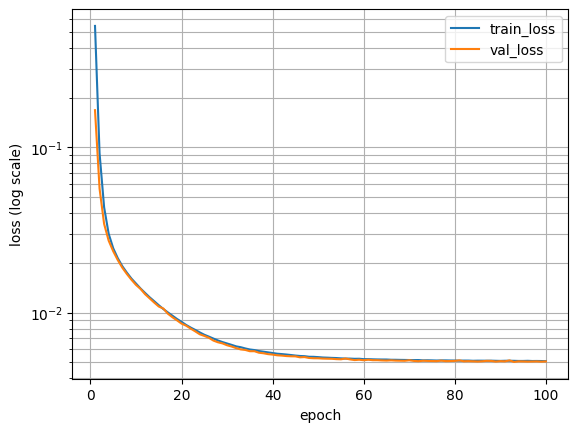

In [276]:
plt.figure()
plt.plot(epochs,train,label="train_loss")
if val is not None:
    plt.plot(epochs,val,label="val_loss")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("loss (log scale)")
plt.legend()
plt.grid(True, which="both")
plt.show()

/tmp/ipykernel_498/1623944902.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


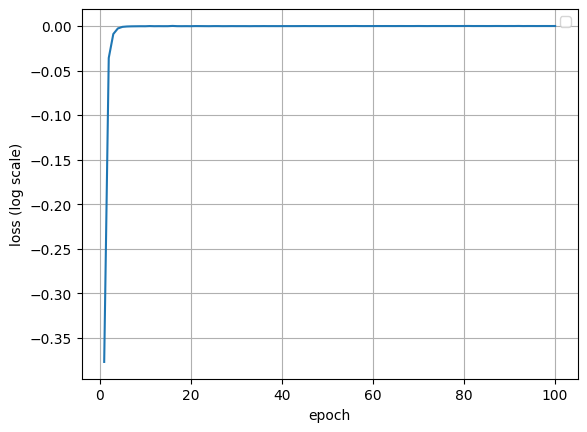

In [ ]:
plt.figure()
plt.plot(epochs,val-train)
plt.xlabel("epoch")
plt.ylabel("val_loss - train_loss")
plt.grid(True)
plt.show()